In [2]:
import os, sys
from transformers import RobertaTokenizer, RobertaConfig, Trainer, TrainingArguments
from safetensors import safe_open
import torch
import pandas as pd
from datasets import Dataset

sys.path.append("../")
from utils.parameters import *
from train_two_tower_model.two_tower_models import DualTowerForSequenceClassification_visual

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
config = RobertaConfig(
    vocab_size_1=9, # 9 for base, 10_000 for bpe
    vocab_size_2=10_000,
    hidden_size=256, # embedding size
    max_position_embeddings=128,
    num_decoder_layers=3,
    num_attention_heads=8,
    intermediate_size=3072,
    type_vocab_size=1,
    pad_token_id=3,
    bos_token_id=0,
    eos_token_id=1,
    position_embedding_type="relative_key",
)
# * tower model
tower_model = DualTowerForSequenceClassification_visual(config, is_pretrained=True, pretrained_version=5)
tensors = {}
with safe_open(SAVED_MODEL_DIR_SEMI_V2+"/model.safetensors", framework="pt") as f:
    for k in f.keys():
        tensors[k] = f.get_tensor(k)
tower_model.load_state_dict(tensors)
tower_model.to(device)

tokenizer1 = RobertaTokenizer.from_pretrained(TOKEN_DIR_BASE)
tokenizer2 = RobertaTokenizer.from_pretrained(TOKEN_DIR_BPE)

Pretrained weights loaded successfully. (v5)


In [4]:
CTRACT_DICT = {
    "CCC": 5,
    "CCCC": 6,
    "CCCCC": 7,
    "CCCCCC": 8,
    "CCCCCCC": 9,
    "CCCCCCCC": 10,
    "CCCCCCCCC": 11,
    "CCCCCCCCCC": 12,
    "CCCCCCCCCCC": 13,
    "CCCCCCCCCCCC": 14,
    "CCCCCCCCCCCCC": 15,
    "CCCCCCCCCCCCCC": 16,
    "CCCCCCCCCCCCCCC": 17,
}
CTRACT_ID_SET = set(CTRACT_DICT.values())
CTRACT_ID_TRANS = {
    5: 1, 6: 1, 7: 1, 8: 1, 9: 2,
    10: 2, 11: 2, 12: 2, 13: 3, 14: 3, 15: 3, 16: 3, 17: 4
}

def count_c_tracts(file_path):
    samples = pd.read_csv(file_path, header=None, names=["sequence"])

    dataset = Dataset.from_pandas(samples)

    # Tokenize the sequences
    def tokenize_function(examples):
        tokens1 = tokenizer1(examples["sequence"], padding="max_length", max_length=MAX_LEN_BASE)
        tokens2 = tokenizer2(examples["sequence"], padding="max_length", max_length=MAX_LEN_BPE)
        ctract_nums = list()
        for i in tokens2["input_ids"]:
            countr = 0
            for j in range(MAX_LEN_BPE):
                if i[j] in CTRACT_ID_SET:
                    countr += CTRACT_ID_TRANS[i[j]]
            # if countr == 10:
            #     print(i)
            ctract_nums.append(countr)
        return {"input_ids_1": tokens1["input_ids"], "input_ids_2": tokens2["input_ids"], "ctract_nums": ctract_nums}

    tokenized_dataset = dataset.map(tokenize_function, batched=True)
    return tokenized_dataset

positive_dataset = count_c_tracts(os.path.join(SAMPLES_PATH, "distinct_positive_samples_HEK293T.csv"))
negative_dataset = count_c_tracts(os.path.join(SAMPLES_PATH, "distinct_negative_samples_HEK293T.csv"))
pseudo_pos_dataset = count_c_tracts(os.path.join(PSEUDO_SAMPLES_PATH, "pseudo_positive_samples_HEK293T_v2.csv"))
pseudo_neg_dataset = count_c_tracts(os.path.join(PSEUDO_SAMPLES_PATH, "pseudo_negative_samples_HEK293T_v2.csv"))

Map:   0%|          | 0/13708 [00:00<?, ? examples/s]

Map:   0%|          | 0/28717 [00:00<?, ? examples/s]

Map:   0%|          | 0/10276 [00:00<?, ? examples/s]

Map:   0%|          | 0/2137 [00:00<?, ? examples/s]

In [5]:
print(min(positive_dataset['ctract_nums']), max(positive_dataset['ctract_nums']))
print(min(negative_dataset['ctract_nums']), max(negative_dataset['ctract_nums']))
print(min(pseudo_pos_dataset['ctract_nums']), max(pseudo_pos_dataset['ctract_nums']))
print(min(pseudo_neg_dataset['ctract_nums']), max(pseudo_neg_dataset['ctract_nums']))

4 12
4 10
4 10
4 10


In [6]:
# Perform prediction 对四种数据全都预测
BATCH_SIZE = 1024
tower_model.eval()
positive_xy = list()
negative_xy = list()
pseudo_pos_xy = list()
pseudo_neg_xy = list()
with torch.no_grad():
    outputs_tower = torch.Tensor([])
    outputs_tower = outputs_tower.to(device)
    i = 0
    while batched_inputs := {"input_ids_1": torch.tensor(positive_dataset["input_ids_1"][i*BATCH_SIZE:(i+1)*BATCH_SIZE]).to(device), "input_ids_2": torch.tensor(positive_dataset["input_ids_2"][i*BATCH_SIZE:(i+1)*BATCH_SIZE]).to(device)}:
        if len(batched_inputs["input_ids_1"]) == 0:
            break
        outputs_tower = torch.cat((outputs_tower, tower_model(**batched_inputs).logits), dim=0)
        i += 1
    for j in range(len(positive_dataset["input_ids_1"])):
        positive_xy.append((positive_dataset["ctract_nums"][j], outputs_tower[j][1].cpu().item()))

    outputs_tower = torch.Tensor([])
    outputs_tower = outputs_tower.to(device)
    i = 0
    while batched_inputs := {"input_ids_1": torch.tensor(negative_dataset["input_ids_1"][i*BATCH_SIZE:(i+1)*BATCH_SIZE]).to(device), "input_ids_2": torch.tensor(negative_dataset["input_ids_2"][i*BATCH_SIZE:(i+1)*BATCH_SIZE]).to(device)}:
        if len(batched_inputs["input_ids_1"]) == 0:
            break
        outputs_tower = torch.cat((outputs_tower, tower_model(**batched_inputs).logits), dim=0)
        i += 1
    for j in range(len(negative_dataset["input_ids_1"])):
        negative_xy.append((negative_dataset["ctract_nums"][j], outputs_tower[j][1].cpu().item()))

    outputs_tower = torch.Tensor([])
    outputs_tower = outputs_tower.to(device)
    i = 0
    while batched_inputs := {"input_ids_1": torch.tensor(pseudo_pos_dataset["input_ids_1"][i*BATCH_SIZE:(i+1)*BATCH_SIZE]).to(device), "input_ids_2": torch.tensor(pseudo_pos_dataset["input_ids_2"][i*BATCH_SIZE:(i+1)*BATCH_SIZE]).to(device)}:
        if len(batched_inputs["input_ids_1"]) == 0:
            break
        outputs_tower = torch.cat((outputs_tower, tower_model(**batched_inputs).logits), dim=0)
        i += 1
    for j in range(len(pseudo_pos_dataset["input_ids_1"])):
        pseudo_pos_xy.append((pseudo_pos_dataset["ctract_nums"][j], outputs_tower[j][1].cpu().item()))

    outputs_tower = torch.Tensor([])
    outputs_tower = outputs_tower.to(device)
    i = 0
    while batched_inputs := {"input_ids_1": torch.tensor(pseudo_neg_dataset["input_ids_1"][i*BATCH_SIZE:(i+1)*BATCH_SIZE]).to(device), "input_ids_2": torch.tensor(pseudo_neg_dataset["input_ids_2"][i*BATCH_SIZE:(i+1)*BATCH_SIZE]).to(device)}:
        if len(batched_inputs["input_ids_1"]) == 0:
            break
        outputs_tower = torch.cat((outputs_tower, tower_model(**batched_inputs).logits), dim=0)
        i += 1
    for j in range(len(pseudo_neg_dataset["input_ids_1"])):
        pseudo_neg_xy.append((pseudo_neg_dataset["ctract_nums"][j], outputs_tower[j][1].cpu().item()))

In [7]:
import numpy as np

def get_part(xy_dict):
    # 从每个 key 类别中取 20 个样本
    part_xy = list()
    SAMPLE_NUM = 20
    interval = len(xy_dict[4])//SAMPLE_NUM
    i = 0
    while i < len(xy_dict[4]):
        part_xy.append((4, xy_dict[4][i]))
        i += interval
    interval = len(xy_dict[5])//SAMPLE_NUM
    i = 0
    while i < len(xy_dict[5]):
        part_xy.append((5, xy_dict[5][i]))
        i += interval
    interval = len(xy_dict[6])//SAMPLE_NUM
    i = 0
    while i < len(xy_dict[6]):
        part_xy.append((6, xy_dict[6][i]))
        i += interval
    interval = len(xy_dict[7])//SAMPLE_NUM
    i = 0
    while i < len(xy_dict[7]):
        part_xy.append((7, xy_dict[7][i]))
        i += interval
    interval = max(len(xy_dict[8])//SAMPLE_NUM, 1)
    i = 0
    while i < len(xy_dict[8]):
        part_xy.append((8, xy_dict[8][i]))
        i += interval
    return np.array(part_xy)

positive_xy_2 = {4:list(), 5:list(), 6:list(), 7:list(), 8:list()}
for i, x in enumerate(positive_xy):
    if x[0] in positive_xy_2.keys():
        positive_xy_2[x[0]].append(x[1])
part_positive_xy = get_part(positive_xy_2)
print(len(part_positive_xy))
pos_averages = [np.mean(positive_xy_2[4]), np.mean(positive_xy_2[5]), np.mean(positive_xy_2[6]), np.mean(positive_xy_2[7]), np.mean(positive_xy_2[8])]
print(pos_averages)

negative_xy_2 = {4:list(), 5:list(), 6:list(), 7:list(), 8:list()}
for i, x in enumerate(negative_xy):
    if x[0] in negative_xy_2.keys():
        negative_xy_2[x[0]].append(x[1])
part_negative_xy = get_part(negative_xy_2)
print(len(part_negative_xy))
neg_averages = [np.mean(negative_xy_2[4]), np.mean(negative_xy_2[5]), np.mean(negative_xy_2[6]), np.mean(negative_xy_2[7]), np.mean(negative_xy_2[8])]
print(neg_averages)

pseudo_pos_xy_2 = {4:list(), 5:list(), 6:list(), 7:list(), 8:list()}
for i, x in enumerate(pseudo_pos_xy):
    if x[0] in pseudo_pos_xy_2.keys():
        pseudo_pos_xy_2[x[0]].append(x[1])
part_pseudo_pos_xy = get_part(pseudo_pos_xy_2)
print(len(part_pseudo_pos_xy))
pse_pos_averages = [np.mean(pseudo_pos_xy_2[4]), np.mean(pseudo_pos_xy_2[5]), np.mean(pseudo_pos_xy_2[6]), np.mean(pseudo_pos_xy_2[7]), np.mean(pseudo_pos_xy_2[8])]
print(pse_pos_averages)

pseudo_neg_xy_2 = {4:list(), 5:list(), 6:list(), 7:list(), 8:list()}
for i, x in enumerate(pseudo_neg_xy):
    if x[0] in pseudo_neg_xy_2.keys():
        pseudo_neg_xy_2[x[0]].append(x[1])
part_pseudo_neg_xy = get_part(pseudo_neg_xy_2)
print(len(part_pseudo_neg_xy))
pse_neg_averages = [np.mean(pseudo_neg_xy_2[4]), np.mean(pseudo_neg_xy_2[5]), np.mean(pseudo_neg_xy_2[6]), np.mean(pseudo_neg_xy_2[7]), np.mean(pseudo_neg_xy_2[8])]
print(pse_neg_averages)

all_averages = [(pos_averages[i]+neg_averages[i]+pse_pos_averages[i]+pse_neg_averages[i])/4 for i in range(5)]
print(all_averages)
labeled_averages = [(pos_averages[i]+neg_averages[i])/2 for i in range(5)]
print(labeled_averages)
pseudo_averages = [(pse_pos_averages[i]+pse_neg_averages[i])/2 for i in range(5)]
print(pseudo_averages)

106
[2.734184609290546, 3.2360002969732906, 3.3839175057462656, 3.2097415254599806, 3.2979697324210147]
104
[-2.688768512225641, -2.998891324783607, -3.063065808878726, -3.0093320981654332, -2.8117220595783117]
105
[2.3376859481092556, 2.7925759366651746, 2.975852764407111, 2.8841148348478667, 3.0190816885465153]
108
[-3.3504251164133296, -3.3474021075803613, -3.3648012891227816, -3.1838500165102777, -3.0207495279610157]
[-0.2418307678097923, -0.0794292996813758, -0.017024206962032773, -0.024831438591965904, 0.12114495835705064]
[0.02270804853245245, 0.11855448609484176, 0.16042584843376972, 0.10020471364727368, 0.2431238364213515]
[-0.506369584152037, -0.27741308545759336, -0.19447426235783527, -0.1498675908312055, -0.0008339197072502191]


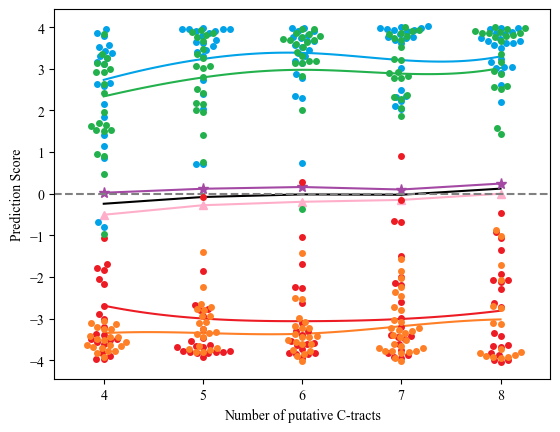

In [8]:
# 画图，横轴是 positive_dataset 的 ctract_nums，纵轴是 outputs_tower 的 第1列
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
plt.rc('font', family='Times New Roman')
fig, ax = plt.subplots()

# 绘制散点图
# sns.catplot(x=part_positive_xy[:, 0], y=part_positive_xy[:, 1], kind="swarm", color="blue")
# sns.catplot(x=part_negative_xy[:, 0], y=part_negative_xy[:, 1], kind="swarm", color="red")
sns.swarmplot(x=part_positive_xy[:, 0], y=part_positive_xy[:, 1], color="#00A2E8", ax=ax)
sns.swarmplot(x=part_negative_xy[:, 0], y=part_negative_xy[:, 1], color="#ED1C24", ax=ax)
sns.swarmplot(x=part_pseudo_pos_xy[:, 0], y=part_pseudo_pos_xy[:, 1], color="#22B14C", ax=ax)
sns.swarmplot(x=part_pseudo_neg_xy[:, 0], y=part_pseudo_neg_xy[:, 1], color="#FF7F27", ax=ax)

# 绘制折线图
# sns.lineplot(x=range(len(pos_averages)), y=pos_averages, color="blue", ax=ax, label="Pos Averages")
# sns.lineplot(x=range(len(neg_averages)), y=neg_averages, color="red", ax=ax, label="Neg Averages")
# sns.lineplot(x=range(len(pse_pos_averages)), y=pse_pos_averages, color="green", ax=ax, label="Pse Pos Averages")
# sns.lineplot(x=range(len(pse_neg_averages)), y=pse_neg_averages, color="orange", ax=ax, label="Pse Neg Averages")

# 创建平滑曲线
def smooth_curve(x, y):
    x_new = np.linspace(x.min(), x.max(), 100)
    spl = make_interp_spline(x, y, k=3)
    y_smooth = spl(x_new)
    return x_new, y_smooth

# 绘制平滑曲线
x = np.arange(len(pos_averages))
x_smooth, y_smooth = smooth_curve(x, pos_averages)
ax.plot(x_smooth, y_smooth, color="#00A2E8", label="Pos Averages")

x = np.arange(len(neg_averages))
x_smooth, y_smooth = smooth_curve(x, neg_averages)
ax.plot(x_smooth, y_smooth, color="#ED1C24", label="Neg Averages")

x = np.arange(len(pse_pos_averages))
x_smooth, y_smooth = smooth_curve(x, pse_pos_averages)
ax.plot(x_smooth, y_smooth, color="#22B14C", label="Pse Pos Averages")

x = np.arange(len(pse_neg_averages))
x_smooth, y_smooth = smooth_curve(x, pse_neg_averages)
ax.plot(x_smooth, y_smooth, color="#FF7F27", label="Pse Neg Averages")

x = np.arange(len(all_averages))
ax.plot(x, all_averages, color="#000000", label="All Averages")
ax.plot(x, labeled_averages, color="#A349A4", label="Labeled Averages", marker="*", markersize=8)
ax.plot(x, pseudo_averages, color="#FFAEC9", label="Pseudo Averages", marker="^")

ax.plot((-0.5, 4.5), (0, 0), color="grey", linestyle="--")

plt.xlim(-0.5, 4.5)
plt.xticks([0,1,2,3,4], [4,5,6,7,8])

plt.xlabel("Number of putative C-tracts")
plt.ylabel("Prediction Score")

# 手动创建图例
# handles = [
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=6, label='Positive'),
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=6, label='Negative')
# ]
# ax.legend(handles=handles)
# plt.legend(loc="best")
# plt.show()
plt.savefig("../figures/ctractnums.eps", format="eps", bbox_inches="tight")
# plt.savefig("../figures/ctractnums.png", format="png", bbox_inches="tight")

### 随着样本C-tract数量增多，样本构成i-Motif的可能性增加
由图中曲线可见：
1. 代表已标注正例均值的蓝线和代表伪标签正例均值的绿线都呈现随着C-tract数量增多整体上升趋势；
2. 代表已标注负例均值的红线随着C-tract数量增多先下降再上升，和代表伪标签负例均值的橙线随着C-tract数量增多一直上升；
3. 代表全部样本均值的黑线随着C-tract数量增多而上升；
因此，可以得出结论：随着样本C-tract数量增多，模型越会认为样本构成i-Motif的可能性增加。

### 模型学习到了不同来源样本的特征
由已标注样本均值的紫线要高于由伪标签样本均值的粉线，可以得出结论：模型学习到了不同来源样本的特征，有能力区分已标注样本和伪标签样本。

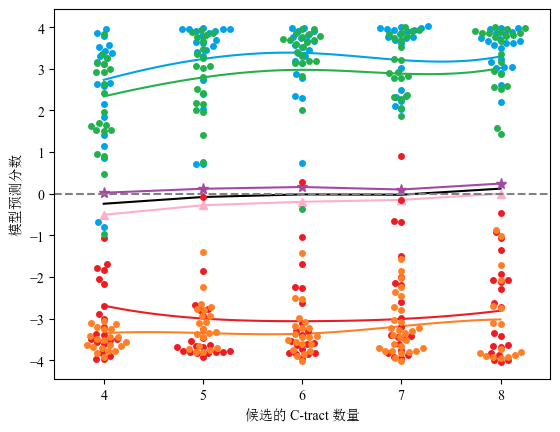

In [9]:
# 画图，横轴是 positive_dataset 的 ctract_nums，纵轴是 outputs_tower 的 第1列
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
# plt.rc('font', family='Times New Roman')
plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
fig, ax = plt.subplots()

# 绘制散点图
# sns.catplot(x=part_positive_xy[:, 0], y=part_positive_xy[:, 1], kind="swarm", color="blue")
# sns.catplot(x=part_negative_xy[:, 0], y=part_negative_xy[:, 1], kind="swarm", color="red")
sns.swarmplot(x=part_positive_xy[:, 0], y=part_positive_xy[:, 1], color="#00A2E8", ax=ax)
sns.swarmplot(x=part_negative_xy[:, 0], y=part_negative_xy[:, 1], color="#ED1C24", ax=ax)
sns.swarmplot(x=part_pseudo_pos_xy[:, 0], y=part_pseudo_pos_xy[:, 1], color="#22B14C", ax=ax)
sns.swarmplot(x=part_pseudo_neg_xy[:, 0], y=part_pseudo_neg_xy[:, 1], color="#FF7F27", ax=ax)

# 绘制折线图
# sns.lineplot(x=range(len(pos_averages)), y=pos_averages, color="blue", ax=ax, label="Pos Averages")
# sns.lineplot(x=range(len(neg_averages)), y=neg_averages, color="red", ax=ax, label="Neg Averages")
# sns.lineplot(x=range(len(pse_pos_averages)), y=pse_pos_averages, color="green", ax=ax, label="Pse Pos Averages")
# sns.lineplot(x=range(len(pse_neg_averages)), y=pse_neg_averages, color="orange", ax=ax, label="Pse Neg Averages")

# 创建平滑曲线
def smooth_curve(x, y):
    x_new = np.linspace(x.min(), x.max(), 100)
    spl = make_interp_spline(x, y, k=3)
    y_smooth = spl(x_new)
    return x_new, y_smooth

# 绘制平滑曲线
x = np.arange(len(pos_averages))
x_smooth, y_smooth = smooth_curve(x, pos_averages)
ax.plot(x_smooth, y_smooth, color="#00A2E8", label="Pos Averages")

x = np.arange(len(neg_averages))
x_smooth, y_smooth = smooth_curve(x, neg_averages)
ax.plot(x_smooth, y_smooth, color="#ED1C24", label="Neg Averages")

x = np.arange(len(pse_pos_averages))
x_smooth, y_smooth = smooth_curve(x, pse_pos_averages)
ax.plot(x_smooth, y_smooth, color="#22B14C", label="Pse Pos Averages")

x = np.arange(len(pse_neg_averages))
x_smooth, y_smooth = smooth_curve(x, pse_neg_averages)
ax.plot(x_smooth, y_smooth, color="#FF7F27", label="Pse Neg Averages")

x = np.arange(len(all_averages))
ax.plot(x, all_averages, color="#000000", label="All Averages")
ax.plot(x, labeled_averages, color="#A349A4", label="Labeled Averages", marker="*", markersize=8)
ax.plot(x, pseudo_averages, color="#FFAEC9", label="Pseudo Averages", marker="^")

ax.plot((-0.5, 4.5), (0, 0), color="grey", linestyle="--")

plt.xlim(-0.5, 4.5)
plt.xticks([0,1,2,3,4], [4,5,6,7,8])

plt.xlabel("候选的 C-tract 数量")
plt.ylabel("模型预测分数")

# 手动创建图例
# handles = [
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=6, label='Positive'),
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=6, label='Negative')
# ]
# ax.legend(handles=handles)
# plt.legend(loc="best")
# plt.show()
plt.savefig("../figures/ctractnums_CN.eps", format="eps", bbox_inches="tight")
# plt.savefig("../figures/ctractnums.png", format="png", bbox_inches="tight")